In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="6"
DEVICE = "cpu"
BATCH_SIZE = 32

import torch

In [3]:
from IPython.display import display
from tqdm import tqdm

In [4]:
import torchvision.transforms.v2.functional as Fv2

# Duke Dataloading Test

In [5]:
from open_vocab_mot.data import DukeMTMCItemBatch, DukeMTMCVideoDataset, collate_duke_mtmc_video_ds, DukeMTMCVideoDatasetVideoKPFBatchSampler, DukeSplit
from open_vocab_mot.definitions import DUKEMTMC_VIDEO_REID_PATH, DUKEMTMC_VIDEO_REID_SIDECAR_PATH

In [6]:
from torch.utils.data import DataLoader

In [7]:
duke_ds = DukeMTMCVideoDataset(
    ds_root=DUKEMTMC_VIDEO_REID_PATH,
    main_split=DukeSplit.TRAIN,
    sidecar_root=DUKEMTMC_VIDEO_REID_SIDECAR_PATH,
    load_image_pil=False,
    load_image_tensor=True,
    load_segmentations=True,
    verbose=True
)

Loading split TRAIN: 369656it [00:00, 682726.63it/s]
Loading split QUERY: 111848it [00:00, 458973.40it/s]
Loading split GALLERY: 445764it [00:00, 635500.26it/s]


In [8]:
test_sample = duke_ds[0]

704 1096 0704_C8_F0034_X131657.jpg


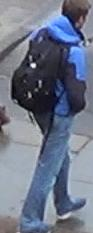

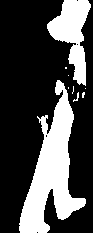

In [9]:
print(test_sample.person_id, test_sample.camera_id, test_sample.frame_name)
display(
    Fv2.to_pil_image(test_sample.frame_tensor),
    Fv2.to_pil_image(test_sample.segmentation_tensor),
)

In [10]:
duke_sampler = DukeMTMCVideoDatasetVideoKPFBatchSampler(
    duke_ds,
    batches_per_epoch=100,
    num_people_per_batch=16,
    num_views_per_person=2,
    num_frames_per_view=16,
    allow_same_person_same_view=False,
    allow_reduced_views_per_person=False,
    allow_resampling_sample_indices=True,
    epoch_deterministic=False,
    seed = 42,
    verbose = True
)

Created a new DukeMTMCVideoDatasetVideoKPFBatchSampler with 512 frames per batch and epoch length of 100
This will mean processing 51200 frames per epoch.


In [11]:
duke_loader = DataLoader(
    dataset=duke_ds,
    collate_fn=collate_duke_mtmc_video_ds,
    batch_sampler=duke_sampler,
    num_workers=4,
    pin_memory=True
)

In [12]:
test_batch_iter = iter(duke_loader)

In [13]:
test_batch: DukeMTMCItemBatch = next(test_batch_iter)

682 1078 0682_C2_F0124_X170553.jpg


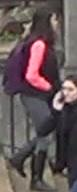

682 1078 0682_C2_F0073_X170298.jpg


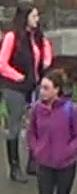

682 1078 0682_C2_F0096_X170413.jpg


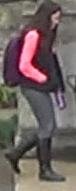

682 1078 0682_C2_F0016_X170013.jpg


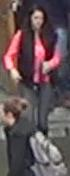

682 1078 0682_C2_F0081_X170338.jpg


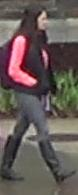

682 1078 0682_C2_F0059_X170228.jpg


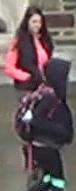

682 1078 0682_C2_F0101_X170438.jpg


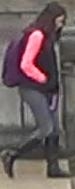

682 1078 0682_C2_F0033_X170098.jpg


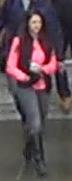

682 1078 0682_C2_F0068_X170273.jpg


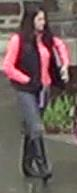

682 1078 0682_C2_F0102_X170443.jpg


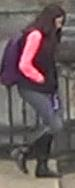

682 1078 0682_C2_F0047_X170168.jpg


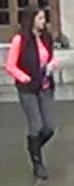

682 1078 0682_C2_F0003_X169948.jpg


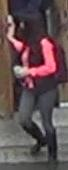

682 1078 0682_C2_F0014_X170003.jpg


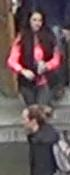

682 1078 0682_C2_F0080_X170333.jpg


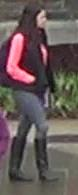

682 1078 0682_C2_F0064_X170253.jpg


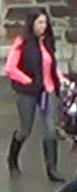

682 1078 0682_C2_F0008_X169973.jpg


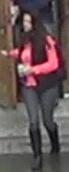

In [14]:
max_viz = 16

test_batch: DukeMTMCItemBatch = next(test_batch_iter)
c = 0
for person_id, camera_id, frame_name, frame_tensor, mask_tensor in zip(test_batch.person_ids, test_batch.camera_ids, test_batch.frame_names, test_batch.frame_tensors, test_batch.segmentations):
    person_id = int(person_id)
    camera_id = int(camera_id)

    print(person_id, camera_id, frame_name)

    display(Fv2.to_pil_image(frame_tensor))
    # display(Fv2.to_pil_image(mask_tensor))

    c += 1
    if c >= max_viz:
        break

In [ ]:
import time
import gc

trials = 6
workers_n_tests = [2, 4, 6, 8, 10, 12, 14, 16]
avg_batch_time_sets = [list() for _ in workers_n_tests]
for trial in range(trials):
    print(f"Starting trial {trial+1}")
    for i, n_workers in enumerate(workers_n_tests):
        print(f"Testing with num workers {n_workers}")
        duke_loader = DataLoader(
            dataset=duke_ds,
            collate_fn=collate_duke_mtmc_video_ds,
            batch_sampler=duke_sampler,
            num_workers=n_workers,
            pin_memory=True
        )

        start_time = time.perf_counter()
        progress = tqdm(duke_loader)
        for batch_idx, _ in enumerate(progress):
            avg_batch_time = (time.perf_counter() - start_time) / (batch_idx + 1)
            progress.set_description_str(f"Avg batch time: {avg_batch_time}")
        
        avg_batch_time = (time.perf_counter() - start_time) / (batch_idx + 1)

        avg_batch_time_sets[i].append(avg_batch_time)

        del duke_loader
        gc.collect()

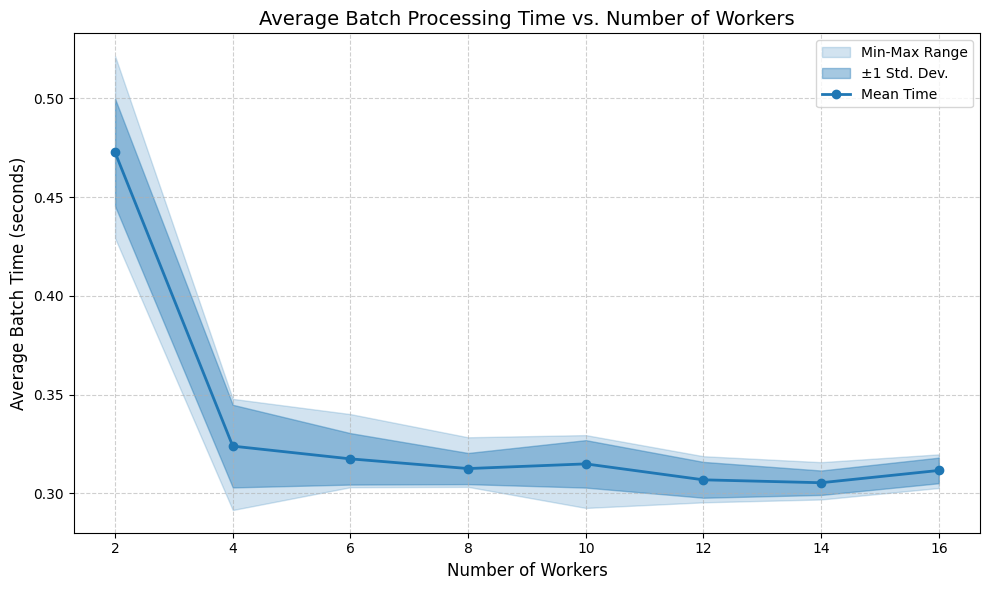

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate statistics
means = np.array([np.mean(tests) for tests in avg_batch_time_sets])
stds = np.array([np.std(tests) for tests in avg_batch_time_sets])
mins = np.array([np.min(tests) for tests in avg_batch_time_sets])
maxs = np.array([np.max(tests) for tests in avg_batch_time_sets])

plt.figure(figsize=(10, 6))

# Plot the full min-max range
plt.fill_between(workers_n_tests, mins, maxs, alpha=0.2, color='tab:blue', label='Min-Max Range')

# Plot the standard deviation range
plt.fill_between(workers_n_tests, means - stds, means + stds, alpha=0.4, color='tab:blue', label='±1 Std. Dev.')

# Plot the mean values
plt.plot(workers_n_tests, means, '-o', color='tab:blue', linewidth=2, label='Mean Time')

# Formatting
plt.title('Average Batch Processing Time vs. Number of Workers', fontsize=14)
plt.xlabel('Number of Workers', fontsize=12)
plt.ylabel('Average Batch Time (seconds)', fontsize=12)
plt.xticks(workers_n_tests)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()
